# 🎬 Netflix Exploratory Data Analysis: Content & Trends

## 1. Executive Summary
This project investigates the Netflix titles dataset to uncover key patterns in content distribution, audience targeting, and regional production trends. The ultimate goal is to extract actionable insights regarding Netflix's catalog strategy to support data-driven decision-making in content acquisition and production.

---

### 🛠️ Tech Stack & Tools
* **Language:** Python
* **Data Manipulation:** `pandas`
* **Data Visualization:** `seaborn`, `matplotlib`

---

### 🎯 Key Objectives
* **Content Distribution:** Analyze the balance and volume analysis between Movies and TV Shows.
* **Audience Targeting:** Examine maturity ratings to understand demographic focus.
* **Regional Trends:** Identify global production hubs and content localization patterns.

## 2. Environment Setup

This section handles the initial configuration of the notebook environment. We import the foundational libraries required for data manipulation and visualization, and establish global aesthetic configurations (such as plot styles, color palettes, and dimensions) to ensure consistent, publication-ready visuals throughout the analysis.

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Configure visualization style
sns.set_theme(style="white")
plt.rcParams['axes.grid'] = False
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Data Acquisition

In this section, we load the raw Netflix dataset into a structural format and perform an initial high-level inspection. This initial look allows us to understand the shape of the dataset, identify available variables, inspect data types, and check for immediate anomalies or missing values before diving into deeper analysis.

In [57]:
dir_path = '/content/drive/MyDrive/Analytics/Dataset/'
name_dataset = 'netflix_titles.csv'
full_path = dir_path + name_dataset
df = pd.read_csv(full_path)
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


## 4. Data Quality Assessment

In this section, we systematically examine the dataframe for missing values, structural anomalies, and duplicate records. Validating data integrity at this stage ensures that subsequent analytical insights and visualizations are built upon a clean, accurate, and reliable foundation.

In [58]:
# Check shape and general info
print(f"Dataset Shape: {df.shape}")
df.info()

# Check for duplicates
print(f"Total Duplicates: {df.duplicated().sum()}")

# Check for missing values
print("\nMissing Values per Column:")
print(df.isna().sum())

Dataset Shape: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
Total Duplicates: 0

Missing Values per Column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating    

### Duplication Check
Executing `df.duplicated().sum()` confirms that there are zero duplicate rows within the dataset. Since all records are unique, no deduplication steps are required, and we can proceed with data integrity intact.

## 5. Data Cleaning & Preprocessing

This section outlines our strategy for handling missing data to ensure a robust analysis. Based on our earlier assessment, the data quality issues are addressed using a two-pronged approach:

* **Strategic Imputation (Missing > 10%):** Columns like `director`, `cast`, and `country` contain substantial missing values. Instead of discarding these records, we fill them with `'Unknown'` to preserve the remaining valid data for regional and talent-based analysis.
* **Targeted Removal (Missing < 1%):** Missing values in `date_added`, `rating`, and `duration` account for a negligible fraction of the dataset. These sparse rows are safely dropped without impacting the overall statistical integrity of the catalog.

In [59]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country']= df['country'].fillna('Unknown')
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [60]:
df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


### Post-Cleaning Verification
In this step, we perform a final diagnostic check on the dataset to verify that all preprocessing and cleaning operations were executed correctly. This ensures that missing values have been handled according to our strategy and the data is now fully prepared for exploratory analysis.

In [61]:
print(df.isna().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [62]:
df.shape

(8790, 12)

## 6. Visualizing Distribution: Movies vs. TV Shows

In this section, we analyze the structural composition of Netflix's library by evaluating the balance between feature films (Movies) and episodic content (TV Shows). Understanding this ratio provides foundational insight into whether Netflix operates primarily as a digital cinema platform or a binge-watch destination, reflecting shifts in consumer engagement strategies.

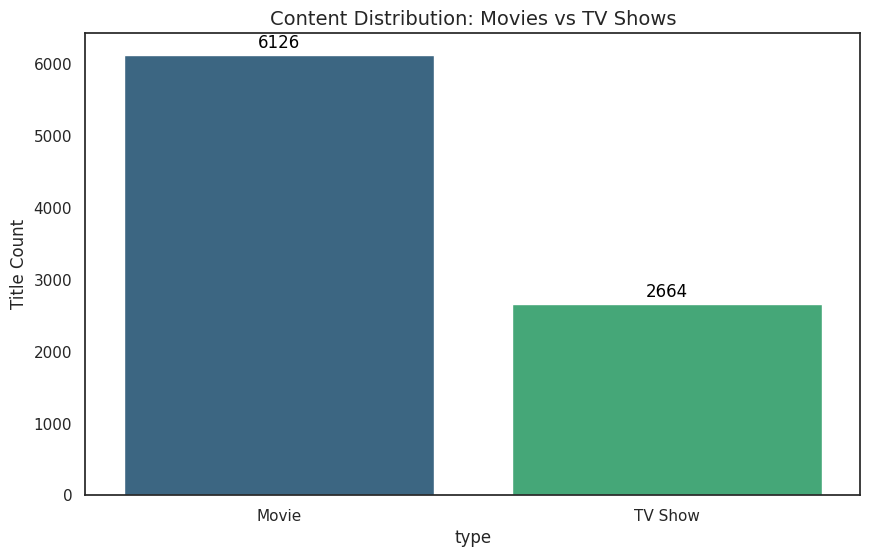

In [77]:
plt.figure(figsize=(10, 6))
counts = df['type'].value_counts()
ax = sns.barplot(
    x=counts.index, y=counts.values,
    hue=counts.index, palette='viridis', legend=False
)
# Annotate bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Content Distribution: Movies vs TV Shows', fontsize=14)
plt.ylabel('Title Count')
ax.grid(False)
plt.show()

Key Insights:
Volume Dominance: Movies significantly outnumber TV Shows (approx. 2.3:1 ratio)
.
Strategic Takeaway: While Netflix started as a movie provider, the growth in TV Shows reflects a strategy to drive long-term subscriber retention through episodic engagement.

## 7. Content Duration Analysis

In this section, we examine the footprint of content runtimes on the platform. Because feature films and episodic series measure duration differently, the analysis is split into two distinct lenses: evaluating movie lengths in minutes to identify typical runtime windows, and analyzing TV show longevity by the number of seasons to gauge series endurance and renewal trends.

In [64]:
df_durationbytype = df.groupby(['type','duration']).size().reset_index(name = 'count')
df_durationbytype

,type,duration,count
0,Movie,10 min,1
1,Movie,100 min,108
2,Movie,101 min,116
3,Movie,102 min,122
4,Movie,103 min,114
...,...,...,...
215,TV Show,5 Seasons,64
216,TV Show,6 Seasons,33
217,TV Show,7 Seasons,23
218,TV Show,8 Seasons,17


In [65]:
df_Movieduration = df_durationbytype[df_durationbytype['type'] == 'Movie']
df_TVShowduration = df_durationbytype[df_durationbytype['type'] == 'TV Show']

In [66]:
df_Movieduration['duration'] = df_Movieduration['duration'].str.replace(' min', '')
df_TVShowduration['duration'] = df_TVShowduration['duration'].str.replace(' Seasons', '')
df_TVShowduration['duration'] = df_TVShowduration['duration'].str.replace(' Season', '')

df_Movieduration['duration'] = pd.to_numeric(df_Movieduration['duration'])
df_TVShowduration['duration'] = pd.to_numeric(df_TVShowduration['duration'])

In [67]:
df_TVShowduration = df_TVShowduration.drop(columns = ['type'])
df_TVShowduration

,duration,count
205,1,1791
206,10,6
207,11,1
208,12,2
209,13,2
210,15,2
211,17,1
212,2,421
213,3,198
214,4,94


In [68]:
df_Movieduration = df_Movieduration.drop(columns=['type'])
df_Movieduration

,duration,count
0,10,1
1,100,108
2,101,116
3,102,122
4,103,114
...,...,...
200,95,137
201,96,130
202,97,146
203,98,120


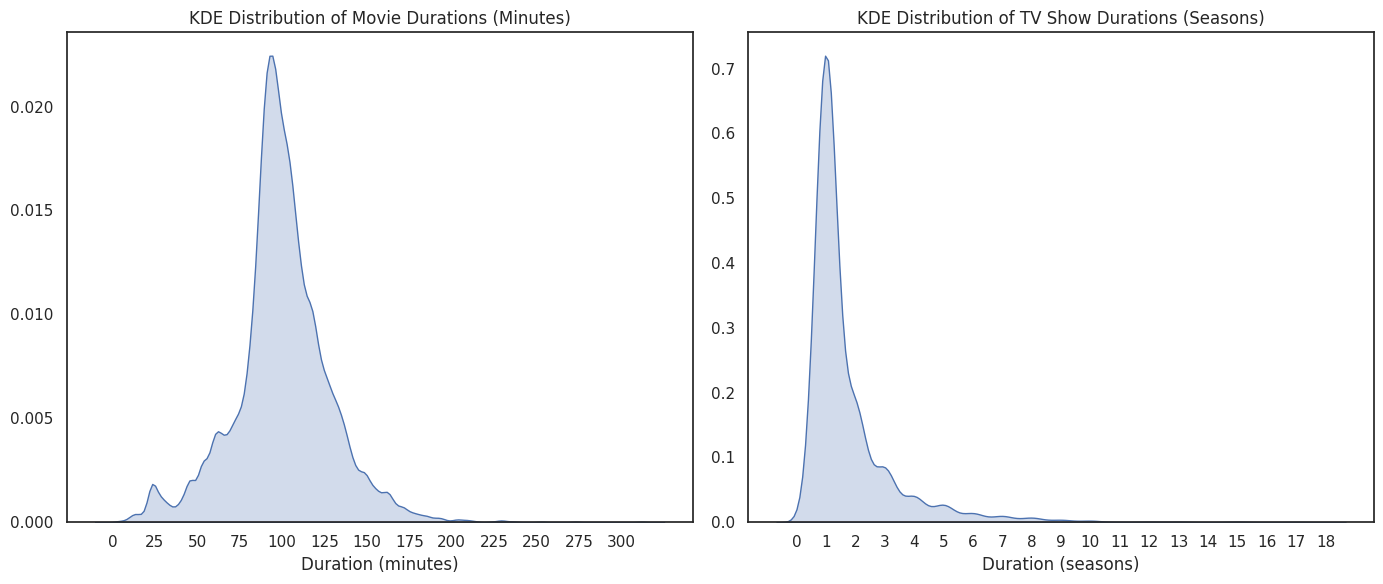

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Movie Duration
sns.kdeplot(data=df_Movieduration, x='duration', weights='count', bw_adjust=0.2, fill=True, ax=ax[0])
ax[0].set_title('KDE Distribution of Movie Durations (Minutes)')
ax[0].set_xlabel('Duration (minutes)')
ax[0].set_ylabel('') # Remove y-axis label as requested
ax[0].set_xticks(range(0, int(df_Movieduration['duration'].max()) + 1, 25))

# Plot for TV Show Duration
sns.kdeplot(data=df_TVShowduration, x='duration', weights='count', bw_adjust=0.2, fill=True, ax=ax[1])
ax[1].set_title('KDE Distribution of TV Show Durations (Seasons)')
ax[1].set_xlabel('Duration (seasons)')
ax[1].set_ylabel('') # Remove y-axis label as requested
ax[1].set_xticks(range(0, int(df_TVShowduration['duration'].max()) + 2, 1))

plt.tight_layout()
plt.show()

### Key Insights: Content Duration Analysis

* **Movies (Optimal Runtime):** The duration distribution is right-skewed, exhibiting a clear, prominent peak between **75 and 125 minutes**. This indicates an industry "sweet spot" where the vast majority of feature films are concentrated to maximize viewer engagement without causing fatigue.
* **TV Shows (High-Volume, High-Churn):** A massive drop-off occurs immediately after Season 1. This trend reveals a clear **"High Volume, High Churn"** content strategy—Netflix aggressively greenlights new titles to test audience appetite, but selectively renews only the highest-performing shows for subsequent seasons.

## 8. Target Audience Analysis (Ratings)

In this section, we analyze the distribution of maturity ratings across the Netflix catalog to identify the platform's primary target demographics. By mapping content classifications (such as TV-MA, TV-14, and PG-13), we can decode Netflix's content curation strategy—revealing whether the library leans heavily toward mature audiences, family-friendly viewers, or a balanced multi-demographic approach.

In [70]:
df_rating = df.groupby('rating').size().sort_values(ascending=False).reset_index(name='count')
df_rating

,rating,count
0,TV-MA,3205
1,TV-14,2157
2,TV-PG,861
3,R,799
4,PG-13,490
5,TV-Y7,333
6,TV-Y,306
7,PG,287
8,TV-G,220
9,NR,79


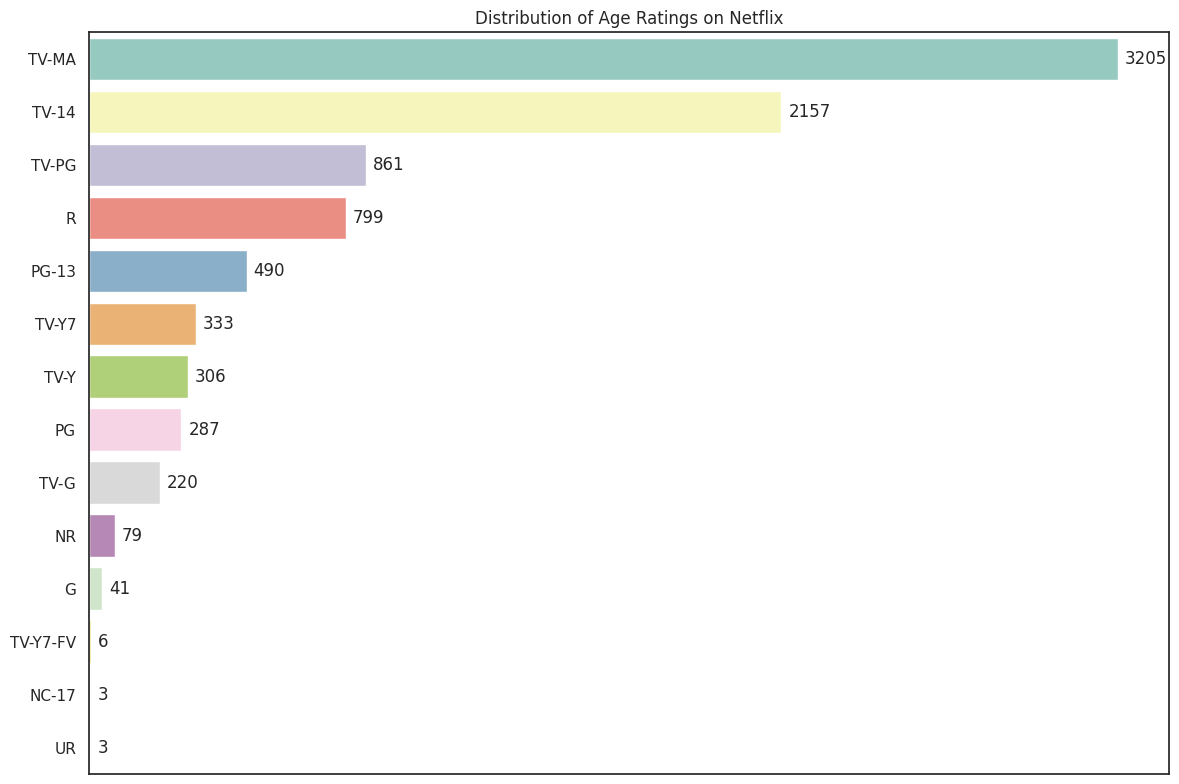

In [71]:
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='count', y='rating', data=df_rating, hue='rating', palette='Set3', legend=False)
plt.title('Distribution of Age Ratings on Netflix')
plt.xlabel('')
plt.ylabel('')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5)

ax.set_xticks([])
plt.tight_layout()
plt.show()

### Content Rating Classification and Definitions

The dataset contains maturity ratings regulated by the **TV Parental Guidelines** (for television shows) and the **MPA** (Motion Picture Association, for movies). To optimize data visualization and model building, these ratings can be consolidated into four primary target audience groups.

| Rating | Official English Definition | Target Audience Group |
| :--- | :--- | :--- |
| **TV-Y** | Designed for all children. Suitable for all ages. | Kids |
| **TV-Y7** | Designed for children age 7 and older. | Kids |
| **TV-G** | Suitable for all audiences. General audience. | Family / All Ages |
| **TV-PG** | Parental guidance is suggested. May contain material unsuitable for younger kids. | Family / Older Kids |
| **TV-14** | Parents strongly cautioned. May contain material unsuitable for children under 14. | Teens / Mature |
| **TV-MA** | Mature audience only. Specifically designed to be viewed by adults. | Mature |
| **G** | General audiences. All ages admitted. | Kids / All Ages |
| **PG** | Parental guidance suggested. Some material may not be suitable for children. | Family / Older Kids |
| **PG-13** | Parents strongly cautioned. Some material may be inappropriate for children under 13. | Family / Older Kids |
| **R** | Restricted. Under 17 requires accompanying parent or adult guardian. | Mature |
| **NC-17** | No one 17 and under admitted. Clearly adult. | Mature |
| **NR** | Not Rated. The film has not been submitted for an official rating. | Unrated / Missing |
| **UR** | Unrated. Typically applies to director's cuts or international content versions. | Unrated / Missing |

---

> **Data Preprocessing Insight:** Categorizing the 13 raw rating classes into **Kids**, **Family**, **Mature**, and **Unrated** drastically reduces label noise, simplifies visualization plots (like countplots or stacked bar charts), and improves statistical significance during analysis.

### Key Insights: Target Audience Analysis

* **Mature Content Focus:** Content classified under **TV-MA** (Mature Audiences Only) and **TV-14** (Parents Strongly Cautioned) represents the vast majority of the catalog. These two classifications heavily outpace family or child-friendly ratings.
* **Strategic Market Positioning:** By prioritizing adult-oriented programming, Netflix intentionally differentiates its brand identity from family-centric platforms such as Disney+. Targeting an older demographic aligns perfectly with subscription monetization, as adult viewers hold the primary purchasing power and financial independence required to sustain recurring subscription revenue.

## 9. Geographic Analysis

In this section, we map the global distribution of Netflix's catalog to identify the primary geographic hubs driving content production. By isolating and counting production footprints by country, we can highlight the dominant regional markets, track the platform's reliance on domestic (US) output, and uncover the scale of its international expansion and localized content strategies.

In [72]:
df.groupby('country').size().reset_index(name='count').sort_values(by='count', ascending=False)

,country,count
603,United States,2809
251,India,972
736,Unknown,829
506,United Kingdom,418
319,Japan,243
...,...,...
12,"Argentina, Uruguay, Serbia",1
11,"Argentina, United States, Mexico",1
10,"Argentina, United States",1
8,"Argentina, Italy",1


In [83]:
df_countries = df.assign(country=df['country'].str.split(', ')).explode('country')
df_countries['country'] = df_countries['country'].str.strip().str.rstrip(',')
df_countries = df_countries.groupby('country').size().sort_values(ascending=False).reset_index(name='count')
df_countries

,country,count
0,United States,3681
1,India,1046
2,Unknown,829
3,United Kingdom,805
4,Canada,445
...,...,...
119,Somalia,1
120,Samoa,1
121,Sudan,1
122,Uganda,1


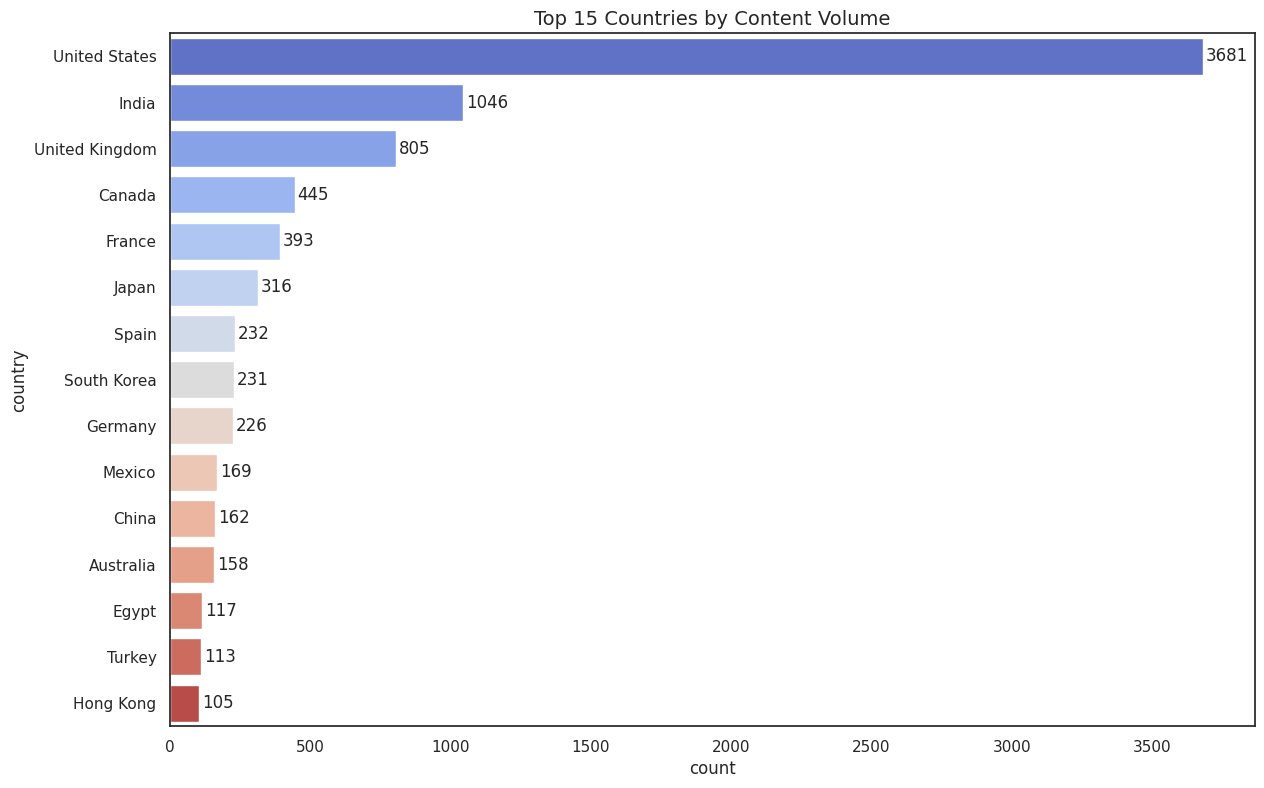

In [84]:
top15 = df_countries[df_countries['country'] != 'Unknown'].head(15)

plt.figure(figsize=(14, 9))
ax = sns.barplot(x='count', y='country', data=top15, hue='country', palette='coolwarm', legend=False)
plt.title('Top 15 Countries by Content Volume', fontsize=14)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=2)

ax.grid(False)
plt.show()

### Key Insights: Geographic Analysis

* **Global Leader:** The United States remains the undisputed primary production hub for Netflix content, maintaining a substantial lead over all other territories.
* **Hyper-Localization Strategy:** India emerges as a powerful second, commanding a massive share of the catalog. This regional focus serves as a critical strategic lever to capture and penetrate the highly competitive Asia-Pacific (APAC) market.
* **European & Commonwealth Strength:** Beyond the top two hubs, the United Kingdom, Canada, and France show significant production volumes. This indicates a strong, established foothold in Western markets and a highly effective approach to capturing global English-speaking audiences.
* **Emerging Asian Hubs:** The prominent presence of South Korea and Japan within the Top 10 underscores the growing strategic importance of East Asian content (such as K-dramas and Anime) in fueling Netflix’s global library and driving international subscriber engagement.

## 10. Strategic Business Recommendations

Based on the empirical insights gathered throughout this Exploratory Data Analysis, the following strategic actions are recommended to optimize Netflix's catalog efficiency, improve operational data quality, and maximize subscriber monetization:

* **Optimize TV Show Renewal & Retention:** To combat the massive drop-off observed after Season 1, Netflix should implement data-driven marketing interventions for high-potential series. Bridging the production gap between Season 1 and Season 2 with targeted viewer engagement will help maintain momentum and reduce subscriber churn.
* **Accelerate Regional Expansion Hubs:** Capitalize on the proven success of international markets by continuing hyper-localization investments in **India** and **South Korea**. These regions are high-volume, high-engagement content hubs capable of driving net-new subscriber growth across global markets.
* **Standardize Content Length:** Maintain the **90–120 minute format** as the baseline production standard for original feature films. Aligning new releases with this audience "sweet spot" ensures optimal resource allocation while matching user viewing habits.
* **Enhance Metadata Integrity (Operational):** Establish stricter data ingestion pipelines to eliminate data gaps, such as the 'Unknown' entries found in regional and talent-based fields. Improving metadata collection will enable more precise regional targeting and significantly boost recommendation engine accuracy.